PART 1

In [ ]:
#@title Mount your Google Drive

import os
from google.colab import drive

try:
  drive.mount('/content/gdrive')

  DRIVE_PATH = '/content/gdrive/My\ Drive/cs182hw4_sp25'
  DRIVE_PYTHON_PATH = DRIVE_PATH.replace('\\', '')
  if not os.path.exists(DRIVE_PYTHON_PATH):
    %mkdir $DRIVE_PATH

  ## the space in `My Drive` causes some issues,
  ## make a symlink to avoid this
  SYM_PATH = '/content/cs182hw4'
  if os.path.isdir(SYM_PATH):
    raise Exception(f"Path already exists - please delete {SYM_PATH} before mounting again.")
  else:
    !ln -sf $DRIVE_PATH $SYM_PATH
except Exception as e:
  print(e)
  print("WARNING - Unable to mount google drive for storing logs. Storing logs in the runtime. Please keep downloading the logs to avoid losing data if the runtime terminates.")
  os.makedirs('/content/cs182hw4/', exist_ok=True)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Path already exists - please delete /content/cs182hw4 before mounting again.
WARNING - Unable to mount google drive for storing logs. Storing logs in the runtime. Please keep downloading the logs to avoid losing data if the runtime terminates.


In [ ]:
#@title Install dependencies

!pip install gputil

In [ ]:
import gc
import GPUtil
import os
import subprocess
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import time


ROOT_PATH = '/content/cs182hw4/'

# Define the CSV format for logging memory usage. Used later in this notebook.
MEMORY_LOG_FMT = ['timestamp', 'memUsage']
TRAIN_LOG_FMT = ['timestamp', 'epoch', 'memUsage', 'loss', 'accuracy']

if torch.cuda.is_available():
  print("Using GPU.")
  device = torch.device("cuda:0")
else:
  print("!!! WARNING !!! - Could not find a GPU - please use a GPU for this homework! If you're on Colab, change your runtime to GPU.")
  device = torch.device("cpu")

%matplotlib inline
%load_ext autoreload
%autoreload 2

Using GPU.


In [ ]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

def get_allocated_memory_str():
    return "Allocated memory: {:.2f} GB".format(torch.cuda.memory_allocated(device) / 1e9)

def run_nvidia_smi():
    if torch.cuda.is_available():
      print(subprocess.check_output("nvidia-smi", shell=True).decode("utf-8"))
    else:
      print("Running on CPU")

def get_gpu_memory_usage() -> float:
    # Use GPUtil python library to get GPU memory usage
    if torch.cuda.is_available():
      return GPUtil.getGPUs()[0].memoryUsed
    else:
      return 0

def cleanup_memory():
    gc.collect()
    torch.cuda.empty_cache()

# Define transformations for the input data. We resize the 32x32 inputs to
# 224x224 which is the input shape for the ResNet family of models.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to 224x224 for ResNet models
    transforms.ToTensor()
])

data_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
data_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


# We randomly subsample the dataset here to train our models faster for this notebook
SUBSAMPLE_SIZE = 1024*4
random_sample_idxs = torch.randint(len(data_train), (SUBSAMPLE_SIZE,))
subsampled_train_data = torch.utils.data.Subset(data_train, indices=random_sample_idxs)

In [ ]:
def analyze_model_and_inputs(model):
    print("Train data size: {}".format(len(data_train)))
    print("Test data size: {}".format(len(data_test)))

    # Fetch an example image to get image size
    image, label = data_train[0]
    print("Image input size: {}".format(image.size()))

    # Get model parameter count
    print("Model parameters: {}".format(sum(p.numel() for p in model.parameters() if p.requires_grad)))

    # Get model size in MB
    print("Model size estimate (MB): {}".format(sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6))

In [ ]:
model = torchvision.models.resnet152(weights=None, num_classes=10)
model.to(device)  # Load the model into GPU memory
analyze_model_and_inputs(model)

Train data size: 50000
Test data size: 10000
Image input size: torch.Size([3, 224, 224])
Model parameters: 58164298
Model size estimate (MB): 232.657192


In [ ]:
!nvidia-smi

Sun Jul 20 17:00:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |     346MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

PART 2

In [ ]:
# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=10, memory_log_path=None):
    os.makedirs(os.path.dirname(memory_log_path), exist_ok=True)
    with open(memory_log_path, 'w') as f:
      f.write(",".join(MEMORY_LOG_FMT) + "\n")
    for epoch in range(epochs):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            with torch.set_grad_enabled(True):
              # Zero all gradients
              optimizer.zero_grad()

              # Get outputs
              outputs = model(images)

              # Compute loss
              loss = criterion(outputs, labels)
              loss.backward()

              # Run optimizer update step
              optimizer.step()

              # Print stats every 100 iterations
              if i % 100 == 0:
                  gpu_memory_usage = get_gpu_memory_usage()
                  print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, GPU Mem: {}'.format(epoch+1, epochs, i+1, len(train_loader), loss.item(), gpu_memory_usage))
                  memory_log = [str(time.time()), str(gpu_memory_usage)]
                  with open(memory_log_path, 'a') as f:
                    f.write(",".join(memory_log) + "\n")
            del loss, outputs, images, labels  # To get accurate memory usage info

# Memory profiling function
def profile_mem_usage(optimizer_str):
    """
    Profiles the memory usage of ResNet-152 on CIFAR-10 with the specified optimizer.

    optimizer_str: str - Can be either of 'SGD', 'SGD_WITH_MOMENTUM' and 'ADAM'
    """
    # Clean up any dangling objects
    cleanup_memory()
    BATCH_SIZE = 8

    # Since we just want to inspect memory usage, run only one minibatch
    subsampled_data = torch.utils.data.Subset(data_train, range(0, BATCH_SIZE))
    train_loader = torch.utils.data.DataLoader(dataset=subsampled_data,
                                               batch_size=BATCH_SIZE,
                                               shuffle=True)

    # Load model and define loss function
    model = torchvision.models.resnet152(weights=None, num_classes=10)
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    # Choose optimizer
    if optimizer_str == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    elif optimizer_str == 'SGD_WITH_MOMENTUM':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    elif optimizer_str == 'ADAM':
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    else:
        raise NotImplementedError

    memory_log_path = ROOT_PATH + f'logs/resnet152__{optimizer_str}.csv'
    train_model(model, train_loader, criterion, optimizer, epochs=1, memory_log_path=memory_log_path)
    print(f"Memory usage log for {optimizer_str} stored at {memory_log_path}. Restart your runtime (Runtime->Restart Runtime) before running for other optimizers!")

In [ ]:
#profile_mem_usage('SGD')

#profile_mem_usage('SGD_WITH_MOMENTUM')

profile_mem_usage('ADAM')


Epoch [1/1], Step [1/1], Loss: 2.0588, GPU Mem: 2428.0
Memory usage log for ADAM stored at /content/cs182hw4/logs/resnet152__ADAM.csv. Restart your runtime (Runtime->Restart Runtime) before running for other optimizers!


In [ ]:
OPTIMIZER_LIST = ['SGD', 'SGD_WITH_MOMENTUM', 'ADAM']
memory_log_path = ROOT_PATH + 'logs/resnet152__{opt}.csv'

def print_mem_profiling_results():
    print("====== Memory Profiling Results ======")
    for opt in OPTIMIZER_LIST:
        assert os.path.exists(memory_log_path.format(opt=opt)), f'Memory profile not found for {opt}. Have you run profile_mem_usage({opt}) in the above cell?'
        df = pd.read_csv(memory_log_path.format(opt=opt))
        mem_usage = df['memUsage'].iloc[0]
        print(f'{opt}: {mem_usage} MB')

print_mem_profiling_results()

====== Memory Profiling Results ======
SGD: 2182.0 MB
SGD_WITH_MOMENTUM: 2264.0 MB
ADAM: 2428.0 MB


PART 3

In [ ]:
# Test function
def test_model(model, test_loader, label='test'):
    print("Testing model.")
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0

        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Compute accuracy
        accuracy = 100 * correct / total
        print(f'Accuracy of the model on {label} images: {accuracy} %')
        del outputs, images, labels  # To get accurate memory usage info
    return accuracy

# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=10, memory_log_path=None, test_loader = None):
    os.makedirs(os.path.dirname(memory_log_path), exist_ok=True)
    with open(memory_log_path, 'w') as f:
      f.write(",".join(TRAIN_LOG_FMT) + "\n")
    for epoch in range(epochs):
        model.train()
        last_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            with torch.set_grad_enabled(True):
              # Zero all gradients
              optimizer.zero_grad()

              # Get outputs
              outputs = model(images)

              # Compute loss
              loss = criterion(outputs, labels)
              loss.backward()

              # Run optimizer update step
              optimizer.step()

              last_loss = loss.item()
              # Print stats every 100 iterations
              if i % 10 == 0:
                  gpu_memory_usage = get_gpu_memory_usage()
                  print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, GPU Mem: {}'.format(epoch+1, epochs, i+1, len(train_loader), last_loss, gpu_memory_usage))
            del loss, outputs, images, labels  # To get accurate memory usage info

        # Report test or train accuracy at the end of every epoch
        if test_loader:
          accuracy = test_model(model, test_loader, label='test')
        else:
          accuracy = test_model(model, train_loader, label='train')

        # Log results
        memory_log = [str(time.time()), str(epoch+1), str(gpu_memory_usage), str(last_loss), str(accuracy)]
        with open(memory_log_path, 'a') as f:
            f.write(",".join(memory_log) + "\n")

# Set learning rates for different batch sizes (emperically determined and linearly scaled)
LR_MAP = {
    4: 0.0001,
    8: 0.0002,
    16: 0.0004,
    32: 0.0008,
    64: 0.0016,
    128: 0.0032,
    256: 0.0064,
    512: 0.0064,
    1024: 0.0064
}

# Executor function
def run_train(batch_size, epochs=10):
    cleanup_memory()

    lr = LR_MAP[batch_size]
    print(f"Training model with batch size {batch_size} and lr {lr}.")

    train_loader = torch.utils.data.DataLoader(dataset=subsampled_train_data, batch_size=batch_size, shuffle=True)

    # We use a smaller model (resnet18) to train faster
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # Output path for memory logs
    memory_log_path = ROOT_PATH + f'logs/resnet18__{batch_size}.csv'

    # Run training!
    train_model(model, train_loader, criterion, optimizer, epochs=epochs, memory_log_path=memory_log_path)

In [ ]:
# TODO - Run this cell for different batch sizes by uncommenting one line at a time.
#
# Make sure to restart the colab runtime between different runs else your
# memory profiles may be inaccurate!

# Run each batch size for at least 10 epochs. You can configure this to be larger if you like.
epochs = 10

# run_train(4, epochs=epochs)
# run_train(16, epochs=epochs)
# run_train(64, epochs=epochs)
# run_train(256, epochs=epochs)
run_train(1024, epochs=epochs)

Training model with batch size 1024 and lr 0.0064.


OutOfMemoryError: CUDA out of memory. Tried to allocate 784.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 28.12 MiB is free. Process 365452 has 14.71 GiB memory in use. Of the allocated memory 13.87 GiB is allocated by PyTorch, and 726.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

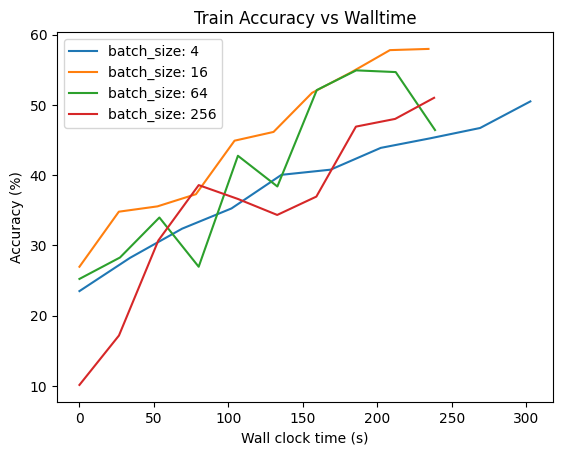


====== Memory Usage for different batch sizes =======
4	: 636.0 MB
16	: 968.0 MB
64	: 2264.0 MB
256	: 8826.0 MB


In [ ]:
# Plotting scripts
def get_df(batch_size):
    path = ROOT_PATH + f'logs/resnet18__{batch_size}.csv'
    assert os.path.exists(path), f'Memory profile not found for batch size {batch_size}. Have you run run_train({batch_size}) in the above cell?'
    df = pd.read_csv(path)
    # Create a wall time column
    df['walltime'] = df['timestamp'] - df['timestamp'].iloc[0]
    return df

def plot_walltime_acc(batch_sizes):
    plt.figure()
    for bs in batch_sizes:
        df=get_df(bs)
        plt.plot(df['walltime'], df['accuracy'], label=f'batch_size: {bs}')
    plt.xlabel('Wall clock time (s)')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Train Accuracy vs Walltime')
    plt.show()

def print_mem_usage(batch_sizes):
    print("\n====== Memory Usage for different batch sizes =======")
    for bs in batch_sizes:
        df=get_df(bs)
        mem_usage = df['memUsage'].iloc[-1]
        print(f'{bs}\t: {mem_usage} MB')

batch_sizes = [4, 16, 64, 256]
plot_walltime_acc(batch_sizes)
print_mem_usage(batch_sizes)